# Практика 1. Pandas и NumPy

В этом ноутбуке разберём, как в Python хранить числа в массивах и таблицы — и быстро считать по ним простые вещи.

**Что нужно уметь к концу занятия**

1. Создать двумерный массив NumPy и брать из него элемент, срез и значения по маске.
2. Складывать и умножать массивы поэлементно.
3. Отличить столбец (`Series`) от таблицы (`DataFrame`).
4. Посмотреть на данные, добавить столбец и построить простой график.
5. Сохранить таблицу в файл и прочитать её обратно.
6. Отбирать строки pandas с помощью масок.
7. Считать среднее и сумму — в том числе после отбора строк.

Запускайте ячейки **сверху вниз**. В четырёх заданиях вместо `...` нужно написать свой код: если решение верное, ячейка напечатает `Верно!`.

## 1. Подготовка окружения

**NumPy** — библиотека для массивов чисел.  
**pandas** — библиотека для таблиц. Внутри она как раз использует NumPy.  
**matplotlib** — библиотека для графиков.

Если импорт ниже не работает, установите пакеты в терминале:

```bash
pip install pandas numpy matplotlib
```

Можно работать и в [Google Colab](https://colab.research.google.com): там эти библиотеки уже есть.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.0.3
numpy: 1.24.4


## 2. NumPy: массивы чисел

Обычный список Python хранит что угодно: числа, строки, другие списки.  
**Массив NumPy** заточен под числа одной формы: строка, таблица, куб.

Зачем он нужен:

- операции применяются **сразу ко всем элементам**, без цикла `for`;
- из массива удобно вырезать куски и отбирать значения по условию;
- таблицы pandas внутри как раз собраны из таких массивов.

Одномерный массив — это ряд чисел.  
**Двумерный** — таблица чисел: первая координата — номер строки, вторая — номер столбца. Подписей у строк и столбцов нет: только индексы, с нуля.

Проще всего собрать одномерный массив — последовательность чисел — функцией `np.arange`. Она похожа на `range` в Python: указываем, **с какого** числа начать, **до какого** дойти (это число уже не входит) и какой **шаг**.

```text
np.arange(старт, стоп, шаг)
```

Если написать одно число, старт будет 0, шаг — 1: `np.arange(5)` даёт `0, 1, 2, 3, 4`.

In [25]:
print("np.arange(5):", np.arange(5))
print("np.arange(2, 8):", np.arange(2, 8))
print("np.arange(0, 10, 2):", np.arange(0, 10, 2))

np.arange(5): [0 1 2 3 4]
np.arange(2, 8): [2 3 4 5 6 7]
np.arange(0, 10, 2): [0 2 4 6 8]


Соберём маленький двумерный массив `grid` — 3 строки и 3 столбца:

In [2]:
grid = np.array(
    [
        [4, 8, 15],
        [16, 23, 42],
        [7, 5, 9],
    ]
)

print(grid)
print("форма (строки, столбцы):", grid.shape)

[[ 4  8 15]
 [16 23 42]
 [ 7  5  9]]
форма (строки, столбцы): (3, 3)


### Индексация

В квадратных скобках через **запятую** сначала строка, потом столбец: `grid[строка, столбец]`.

| Запись | Что берём |
|---|---|
| `grid[0, 1]` | одно число: строка 0, столбец 1 |
| `grid[1]` | вся строка 1 |
| `grid[:, 0]` | весь столбец 0 (`:` означает «все») |
| `grid[:2, 1:]` | **срез**: строки до 2-й (не включая), столбцы с 1-го до конца |

Как и у списка Python, в срезе правая граница **не входит** в результат.

In [3]:
print("одно число grid[0, 1]:", grid[0, 1])
print("строка grid[1]:", grid[1])
print("столбец grid[:, 0]:", grid[:, 0])
print("срез grid[:2, 1:]:")
print(grid[:2, 1:])

одно число grid[0, 1]: 8
строка grid[1]: [16 23 42]
столбец grid[:, 0]: [ 4 16  7]
срез grid[:2, 1:]:
[[ 8 15]
 [23 42]]


### Срез — это view, а не копия

Когда мы пишем `grid[:2, 1:]`, NumPy **не копирует** числа в новый массив. Получается **view** — окно на ту же память.

Поэтому если изменить срез, изменится и исходный массив. Так NumPy экономит время и память.

Если нужна независимая копия, которую можно менять отдельно, вызывают `.copy()`.

In [24]:
board = np.array(
    [
        [4, 8, 15],
        [16, 23, 42],
        [7, 5, 9],
    ]
)

part = board[:2, 1:]
print("срез part (окно на board):")
print(part)

part[0, 0] = 100
print()
print("после part[0, 0] = 100")
print("срез part:")
print(part)
print("весь board:")
print(board)
print()
print("изменился и board: клетка [0, 1] теперь 100")
print("это та же память, что и part[0, 0]")

срез part (окно на board):
[[ 8 15]
 [23 42]]

после part[0, 0] = 100
срез part:
[[100  15]
 [ 23  42]]
весь board:
[[  4 100  15]
 [ 16  23  42]
 [  7   5   9]]

изменился и board: клетка [0, 1] теперь 100
это та же память, что и part[0, 0]


### Поэлементные операции с двумя массивами

Если у двух массивов **одинаковая форма**, `+`, `*` и `==` работают **поэлементно**: первое с первым, второе со вторым и т.д.

`*` здесь — не умножение матриц, а умножение каждой пары чисел.  
`==` возвращает не одно True/False, а массив той же формы.

In [4]:
left = np.array(
    [
        [1, 2, 3],
        [4, 5, 6],
    ]
)
right = np.array(
    [
        [10, 20, 30],
        [40, 50, 60],
    ]
)

print("сложение:")
print(left + right)
print()
print("умножение:")
print(left * right)
print()
print("проверка на равенство с другим массивом:")
print(left == np.array([[1, 0, 3], [4, 5, 0]]))

сложение:
[[11 22 33]
 [44 55 66]]

умножение:
[[ 10  40  90]
 [160 250 360]]

проверка на равенство с другим массивом:
[[ True False  True]
 [ True  True False]]


### Сравнение с числом, логика масок и отбор значений

Сравнение массива с числом тоже поэлементное: получается **маска** — массив из `True` и `False` той же формы.

Две маски соединяют так:

- `&` — и (оба условия верны);
- `|` — или (достаточно одного).

Каждое условие берут в **круглые скобки**.

Если подставить маску в квадратные скобки, останутся только числа, где было `True`. Результат будет **одномерным**: значения идут слева направо, сверху вниз.

In [5]:
print("маска left > 3:")
print(left > 3)
print()
print("два условия сразу: (left > 2) & (left < 6)")
print((left > 2) & (left < 6))
print()
print("или: (left == 1) | (left == 6)")
print((left == 1) | (left == 6))
print()
print("подставляем маску как индекс:")
print(left[(left > 2) & (left < 6)])

маска left > 3:
[[False False False]
 [ True  True  True]]

два условия сразу: (left > 2) & (left < 6)
[[False False  True]
 [ True  True False]]

или: (left == 1) | (left == 6)
[[ True False False]
 [False False  True]]

подставляем маску как индекс:
[3 4 5]


### Задание 1. Массив, срез и маска

Даны очки четырёх игроков в трёх раундах (`scores`) и бонусы за те же раунды (`extra`).

Нужно:

1. Сложить массивы поэлементно и сохранить результат в `final`.
2. Взять срез `scores`: **первые две строки** и **столбцы с 1-го до конца**. Сохранить в `top_right`.
3. Из `final` отобрать числа, которые **больше 6**, причём в той же клетке `scores` значение было **не меньше 4**. Сохранить в `selected`.

Для пункта 3 соберите маску из двух условий через `&` и подставьте её как индекс.

In [ ]:
scores = np.array(
    [
        [4, 8, 6],
        [1, 9, 3],
        [7, 2, 5],
    ]
)
extra = np.array(
    [
        [1, 1, 0],
        [0, 2, 1],
        [1, 0, 2],
    ]
)

print("scores:")
print(scores)
print("extra:")
print(extra)

In [ ]:
final = ...
top_right = ...
selected = ...

assert np.array_equal(final, scores + extra), "final: сложите scores и extra поэлементно"
assert np.array_equal(top_right, np.array([[8, 6], [9, 3]])), "top_right: срез scores[:2, 1:]"
assert np.array_equal(selected, np.array([9, 11, 8, 7])), (
    "selected: возьмите final по маске (final > 6) & (scores >= 4)"
)
print("Верно!")

## 3. Устройство таблицы: Series и DataFrame

Таблицу удобно представлять как лист Excel, только внутри Python.

| Понятие | Что это простыми словами |
|---|---|
| **DataFrame** | вся таблица |
| **Series** | один столбец (или одна строка) |
| **строка** | один объект: один ученик, один день, один товар |
| **столбец** | один признак: имя, возраст, оценка |
| **индекс** | подписи строк слева (по умолчанию 0, 1, 2, ...) |

```
DataFrame
         имя   класс  математика     ← названия столбцов
    0   Анна      9          78     ← строка (один ученик)
    1  Борис      9          91
    ^
    индекс

Столбец «математика» — это Series.
```

Отличие от массива NumPy: у таблицы есть **имена столбцов** и можно смешивать числа с текстом. Дальше соберём небольшую таблицу учеников и на ней посмотрим все операции.

## 4. Создаём простой DataFrame

Самый прямой способ — словарь: ключи станут названиями столбцов, списки — значениями в этих столбцах.  
Длины списков должны совпадать: иначе pandas не поймёт, как собрать таблицу.

In [6]:
students = pd.DataFrame(
    {
        "имя": ["Анна", "Борис", "Вика", "Дима", "Елена", "Фёдор", "Галина", "Игорь"],
        "класс": [9, 9, 10, 10, 9, 10, 9, 10],
        "возраст": [15, 15, 16, 16, 14, 17, 15, 16],
        "математика": [78, 91, 64, 88, 95, 55, 82, 70],
        "информатика": [85, 72, 90, 80, 98, 61, 75, 84],
    }
)

students

,имя,класс,возраст,математика,информатика
0,Анна,9,15,78,85
1,Борис,9,15,91,72
2,Вика,10,16,64,90
3,Дима,10,16,88,80
4,Елена,9,14,95,98
5,Фёдор,10,17,55,61
6,Галина,9,15,82,75
7,Игорь,10,16,70,84


## 5. Как смотреть на таблицу

Несколько команд, которые почти всегда запускают первыми:

- `head()` — первые строки (по умолчанию 5);
- `shape` — сколько строк и столбцов;
- `columns` — список названий столбцов;
- `dtypes` — тип данных в каждом столбце (`int64` — целое число, `object` — обычно текст).

In [ ]:
print("Первые строки:")
display(students.head())

print("Размер (строки, столбцы):", students.shape)
print("Столбцы:", list(students.columns))
print()
print("Типы данных:")
print(students.dtypes)

Первые строки:


,имя,класс,возраст,математика,информатика
0,Анна,9,15,78,85
1,Борис,9,15,91,72
2,Вика,10,16,64,90
3,Дима,10,16,88,80
4,Елена,9,14,95,98


Размер (строки, столбцы): (8, 5)
Столбцы: ['имя', 'класс', 'возраст', 'математика', 'информатика']

Типы данных:
имя            object
класс           int64
возраст         int64
математика      int64
информатика     int64
dtype: object


Один столбец берётся в квадратных скобках. Результат — уже не таблица, а **Series**: те же значения, но с индексом.

In [8]:
math = students["математика"]

print(type(math))
print(math)

<class 'pandas.core.series.Series'>
0    78
1    91
2    64
3    88
4    95
5    55
6    82
7    70
Name: математика, dtype: int64


Несколько столбцов — снова таблица. Для этого названия передают **списком** (двойные квадратные скобки).

In [9]:
students[["имя", "математика", "информатика"]]

,имя,математика,информатика
0,Анна,78,85
1,Борис,91,72
2,Вика,64,90
3,Дима,88,80
4,Елена,95,98
5,Фёдор,55,61
6,Галина,82,75
7,Игорь,70,84


## 6. Простые манипуляции

Чтобы добавить новый столбец в таблицу

Новый столбец можно вычислить из уже существующих. Здесь — средний балл по двум предметам.

`sort_values` сортирует строки. `ascending=False` — от большего к меньшему.

In [10]:
students["средний"] = (students["математика"] + students["информатика"]) / 2

students.sort_values("средний", ascending=False)

,имя,класс,возраст,математика,информатика,средний
4,Елена,9,14,95,98,96.5
3,Дима,10,16,88,80,84.0
0,Анна,9,15,78,85,81.5
1,Борис,9,15,91,72,81.5
6,Галина,9,15,82,75,78.5
2,Вика,10,16,64,90,77.0
7,Игорь,10,16,70,84,77.0
5,Фёдор,10,17,55,61,58.0


## 7. Простые графики

У DataFrame есть метод `plot`. Для сравнения оценок удобен столбчатый график (`kind="bar"`).

Чтобы подписи по оси X были именами, а не номерами строк, сначала ставим столбец `имя` индексом.

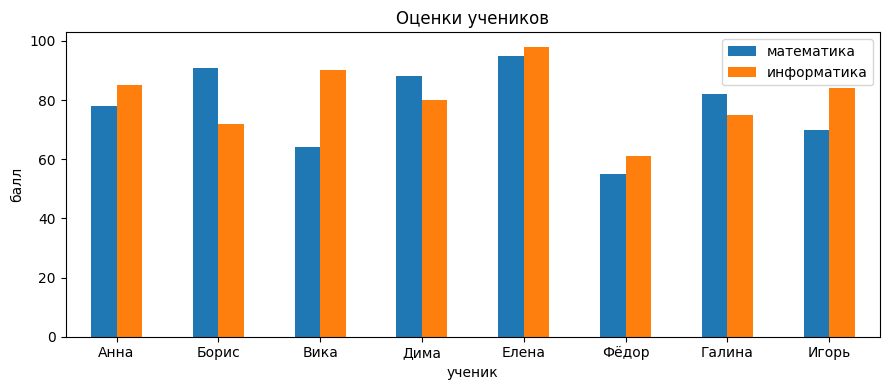

In [15]:
ax = students.set_index("имя")[["математика", "информатика"]].plot(
    kind="bar",
    figsize=(9, 4),
    title="Оценки учеников",
)
ax.set_xlabel("ученик")
ax.set_ylabel("балл")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

Гистограмма показывает, как оценки распределены: сколько человек попало в каждый диапазон баллов.

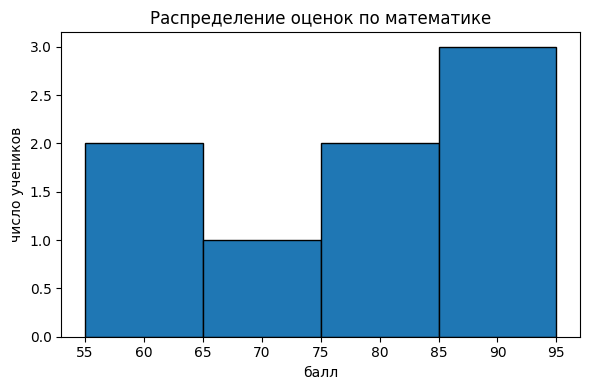

In [16]:
ax = students["математика"].plot(
    kind="hist",
    bins=4,
    figsize=(6, 4),
    title="Распределение оценок по математике",
    edgecolor="black",
)
ax.set_xlabel("балл")
ax.set_ylabel("число учеников")
plt.tight_layout()

## 8. Запись и чтение файла

Таблицу обычно хранят в CSV — это обычный текстовый файл, где значения разделены запятыми.

- `to_csv` — записать на диск;
- `read_csv` — прочитать обратно в DataFrame.

`index=False` нужен, чтобы в файл не попал служебный столбец с номерами строк 0, 1, 2...

In [17]:
students.to_csv("students.csv", index=False, encoding="utf-8")

loaded = pd.read_csv("students.csv", encoding="utf-8")
loaded

,имя,класс,возраст,математика,информатика,средний
0,Анна,9,15,78,85,81.5
1,Борис,9,15,91,72,81.5
2,Вика,10,16,64,90,77.0
3,Дима,10,16,88,80,84.0
4,Елена,9,14,95,98,96.5
5,Фёдор,10,17,55,61,58.0
6,Галина,9,15,82,75,78.5
7,Игорь,10,16,70,84,77.0


После чтения получается такой же DataFrame.

## 9. Индексирование с помощью масок

В pandas маска работает так же, как в NumPy: сравнение столбца с числом даёт набор `True`/`False`.  
`True` означает «эту строку берём», `False` — «эту пропускаем».

Сравнение столбца с числом как раз и даёт такую маску:

In [18]:
mask = students["математика"] >= 80

print("Маска — Series из True/False:")
print(mask)
print()
print("Тип маски:", type(mask))
print("Внутри снова NumPy:", mask.to_numpy())

Маска — Series из True/False:
0    False
1     True
2    False
3     True
4     True
5    False
6     True
7    False
Name: математика, dtype: bool

Тип маски: <class 'pandas.core.series.Series'>
Внутри снова NumPy: [False  True False  True  True False  True False]


Если подставить маску в квадратные скобки, pandas оставит только строки, где значение `True`.

In [19]:
students[mask]

,имя,класс,возраст,математика,информатика,средний
1,Борис,9,15,91,72,81.5
3,Дима,10,16,88,80,84.0
4,Елена,9,14,95,98,96.5
6,Галина,9,15,82,75,78.5


Чаще маску не сохраняют в отдельную переменную, а пишут сразу внутри скобок. Результат тот же:

In [20]:
students[students["класс"] == 9]

,имя,класс,возраст,математика,информатика,средний
0,Анна,9,15,78,85,81.5
1,Борис,9,15,91,72,81.5
4,Елена,9,14,95,98,96.5
6,Галина,9,15,82,75,78.5


Несколько условий соединяют так же, как в NumPy:

- `&` — и (оба условия верны);
- `|` — или (достаточно одного).

Каждое условие обязательно берут в **круглые скобки**. Без них Python сначала попробует сложить `True/False` с числом и выдаст ошибку.

Для «не равно» используют `!=`, для текста — обычное `==`.

In [21]:
students[(students["класс"] == 10) & (students["информатика"] >= 80)]

,имя,класс,возраст,математика,информатика,средний
2,Вика,10,16,64,90,77.0
3,Дима,10,16,88,80,84.0
7,Игорь,10,16,70,84,77.0


### Задание 2. Простая маска

Отберите учеников, у которых оценка по **математике не меньше 80**.

Подсказка: результат должен быть DataFrame, как в примерах выше.  
Замените `...` на выражение вида `students[маска]`.

In [ ]:
high_math = ...

assert isinstance(high_math, pd.DataFrame), "Ожидается таблица DataFrame, а не Series и не число"
assert len(high_math) == 4, "Должно получиться 4 ученика"
assert set(high_math["имя"]) == {"Борис", "Дима", "Елена", "Галина"}
print("Верно!")

### Задание 3. Маска из двух условий

Отберите учеников **10 класса**, у которых оценка по **информатике строго больше 80**.

Нужны оба условия сразу, поэтому используйте `&` и круглые скобки.

In [ ]:
strong_10 = ...

assert isinstance(strong_10, pd.DataFrame), "Ожидается таблица DataFrame"
assert len(strong_10) == 2, "Должно получиться 2 ученика"
assert set(strong_10["имя"]) == {"Вика", "Игорь"}
print("Верно!")

## 10. Функции агрегации: mean и sum

**Агрегация** — свернуть много чисел в одно.

- `mean()` — среднее арифметическое;
- `sum()` — сумма.

Их можно вызывать у столбца (Series) или сразу у нескольких числовых столбцов таблицы.

In [22]:
print("Средняя оценка по математике:", students["математика"].mean())
print("Сумма баллов по информатике:", students["информатика"].sum())
print()
print("Средние по нескольким столбцам:")
print(students[["математика", "информатика", "средний"]].mean())

Средняя оценка по математике: 77.875
Сумма баллов по информатике: 645

Средние по нескольким столбцам:
математика     77.875
информатика    80.625
средний        79.250
dtype: float64


Маска и агрегация часто идут вместе: сначала отбираем нужные строки, потом считаем одно число.

Порядок такой:

1. `students[маска]` — получаем «обрезанную» таблицу;
2. `["столбец"]` — берём один столбец;
3. `.mean()` или `.sum()` — сворачиваем его в число.

In [23]:
math_grade9 = students[students["класс"] == 9]["математика"]

print("Оценки 9 класса по математике:")
print(math_grade9.to_list())
print("Их среднее:", math_grade9.mean())
print("Их сумма:", math_grade9.sum())

Оценки 9 класса по математике:
[78, 91, 95, 82]
Их среднее: 86.5
Их сумма: 346


### Задание 4. Маска + среднее

Посчитайте **среднюю оценку по математике** у учеников **младше 16 лет**.

В переменную должно попасть **число**, а не таблица.

In [ ]:
mean_math_young = ...

assert np.isscalar(mean_math_young), "Нужно одно число, а не таблица или Series"
assert np.isclose(mean_math_young, 86.5), "Среднее посчитано неверно"
print("Верно!")

## Что запомнить

- `np.arange(старт, стоп, шаг)` — последовательность чисел, правая граница не входит.
- Двумерный массив NumPy — таблица чисел без имён столбцов: `массив[строка, столбец]`.
- Срез: `массив[:2, 1:]`. Правая граница в срез не входит.
- Срез — это **view**: правка среза меняет исходный массив. Независимая копия: `.copy()`.
- `+`, `*` и `==` у массивов одной формы работают **поэлементно**.
- Сравнение с числом даёт маску. Маски соединяют через `&` и `|` (со скобками) и подставляют как индекс.
- **DataFrame** — таблица, **Series** — один столбец. Внутри столбца лежит массив NumPy.
- Смотреть на данные: `head`, `shape`, `dtypes`.
- Сохранить / прочитать: `to_csv`, `read_csv`.
- Маска в pandas: `таблица[таблица["столбец"] >= 80]`.
- `mean()` и `sum()` можно вызывать после маски: сначала отбор строк, потом одно число.

Если все четыре задания напечатали `Верно!` — практика выполнена.